In [1]:
import cv2 
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
midas = torch.hub.load('intel-isl/MiDaS','MiDaS_small')
midas.to(device)

Using cache found in C:\Users\HP/.cache\torch\hub\intel-isl_MiDaS_master
D:\Softwares\Anaconda3\envs\new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Softwares\Anaconda3\envs\new\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


Using cache found in C:\Users\HP/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


MidasNet_small(
  (pretrained): Module(
    (layer1): Sequential(
      (0): Conv2dSameExport(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
      (3): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU6(inplace=True)
          (se): Identity()
          (conv_pw): Conv2d(32, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act2): Identity()
        )
      )
      (4): Sequential(
        (0): InvertedResidual(
          (conv_pw): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(144,

In [4]:
midas.eval()

MidasNet_small(
  (pretrained): Module(
    (layer1): Sequential(
      (0): Conv2dSameExport(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
      (3): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act1): ReLU6(inplace=True)
          (se): Identity()
          (conv_pw): Conv2d(32, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
          (act2): Identity()
        )
      )
      (4): Sequential(
        (0): InvertedResidual(
          (conv_pw): Conv2d(24, 144, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(144,

In [5]:
transforms = torch.hub.load('intel-isl/MiDaS','transforms')
transform = transforms.small_transform

Using cache found in C:\Users\HP/.cache\torch\hub\intel-isl_MiDaS_master


In [96]:
import matplotlib.pyplot as plt
def get_square_box(x, y, side_length, img_width, img_height):
    half_side = side_length // 2

    # Calculate raw coordinates
    x_min = x - half_side
    y_min = y - half_side
    x_max = x + half_side
    y_max = y + half_side

    # Clamp coordinates to image boundaries
    x_min = max(0, x_min)
    y_min = max(0, y_min)
    x_max = min(img_width - 1, x_max)
    y_max = min(img_height - 1, y_max)
    
    return (x_min,y_min),(x_max,y_max)
    
# Scale to desired depth range in meters (Example: 0.1m to 100m)
min_depth = 0.1 # 0.1 m
max_depth = 1000.0

Inverted Depth at (110,60) = 68.436 meters


Text(0.5, 1.0, 'Final Image')

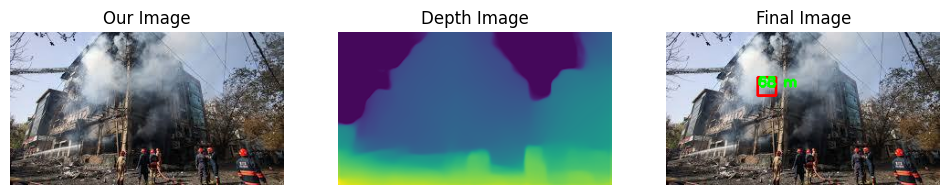

In [97]:
img = cv2.imread("images/image1.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 110, 60
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 20
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),2)
output_img = cv2.putText(output_img,str(round(distance_at_point))+" m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

Inverted Depth at (230,80) = 1000.000 meters


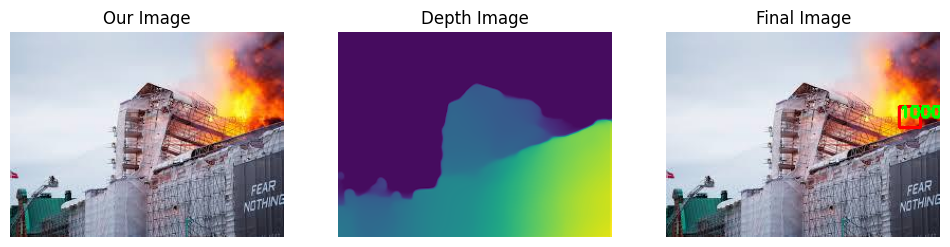

In [103]:
img = cv2.imread("images/image2.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 230, 80
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 20
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),2)
output_img = cv2.putText(output_img,str(round(distance_at_point))+"m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

plt.show()

Inverted Depth at (150,80) = 3.313 meters


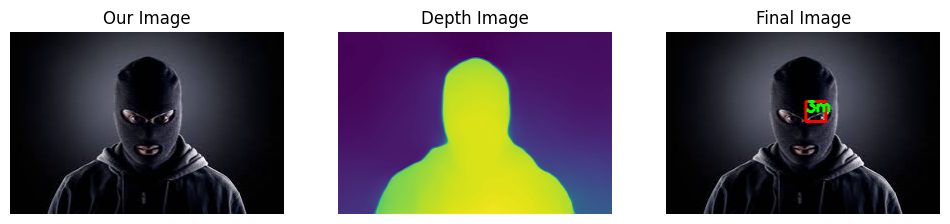

In [107]:
img = cv2.imread("images/a.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 150, 80
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 20
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),2)
output_img = cv2.putText(output_img,str(round(distance_at_point))+"m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

plt.show()

Inverted Depth at (230,80) = 255.654 meters


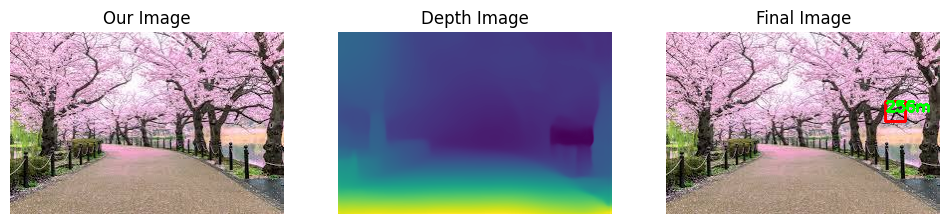

In [108]:
img = cv2.imread("images/image4.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 230, 80
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 20
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),2)
output_img = cv2.putText(output_img,str(round(distance_at_point))+"m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

plt.show()

Inverted Depth at (140,130) = 242.701 meters


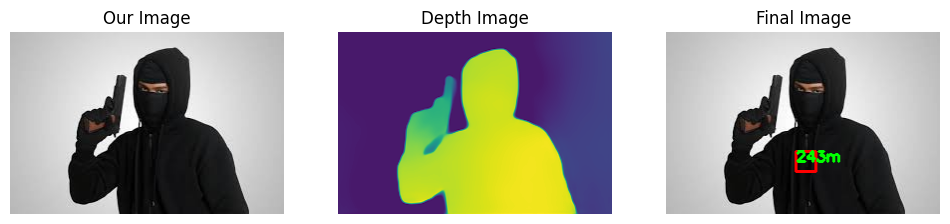

In [113]:
img = cv2.imread("images/b.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 140, 130
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 20
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),2)
output_img = cv2.putText(output_img,str(round(distance_at_point))+"m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

plt.show()

Inverted Depth at (1000,1000) = 540.529 meters


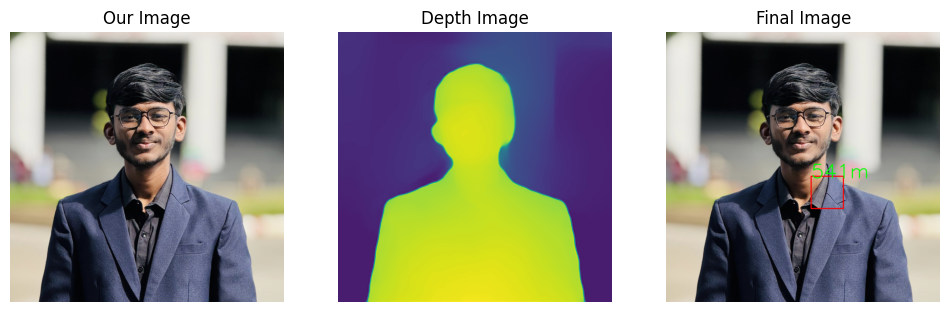

In [119]:
img = cv2.imread("images/image5.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 1000, 1000
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 200
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),6)
output_img = cv2.putText(output_img,str(round(distance_at_point))+"m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,4,(0,255,0),6)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

plt.show()

Inverted Depth at (400,400) = 9.459 meters


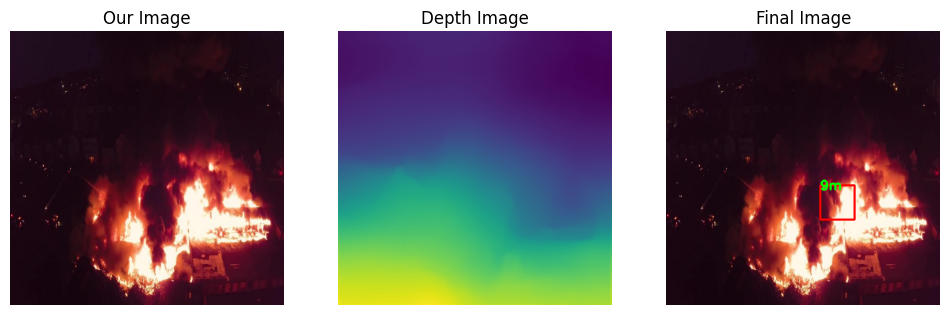

In [122]:
img = cv2.imread("images/image7.jpg")

depth_img_batch = transform(img).to(device)
with torch.no_grad():
    prediction = midas(depth_img_batch)
    prediction = torch.nn.functional.interpolate(
                                        prediction.unsqueeze(1),
                                        size = img.shape[:2],
                                        mode = 'bicubic',
                                        align_corners = False
                                    ).squeeze()
    depth_img = prediction.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
img = cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
plt.imshow(img)
plt.axis('off')
plt.title("Our Image")

plt.subplot(1,3,2)
plt.imshow(depth_img)
plt.axis('off')
plt.title("Depth Image")

# Invert depth map (simple reciprocal inversion)
depth_img_inverted = 1.0 / (depth_img + 1e-6)  # Add small epsilon to avoid divide by zero

# Normalize to a usable depth range (optional scaling)
depth_img_inverted = (depth_img_inverted - depth_img_inverted.min()) / (depth_img_inverted.max() - depth_img_inverted.min())

depth_in_meters = depth_img_inverted * (max_depth - min_depth) + min_depth

# Get depth at specific point
x, y = 400,400
distance_at_point = depth_in_meters[y, x]

print(f"Inverted Depth at ({x},{y}) = {distance_at_point:.3f} meters")


img_height, img_width = depth_img.shape[:2]
side_length = 80
a , b = get_square_box(x, y, side_length, img_width, img_height)

x_txt , y_txt = a
y_txt += 10

output_img = cv2.rectangle(img,a,b,(255,0,0),3)
output_img = cv2.putText(output_img,str(round(distance_at_point))+"m",(x_txt,y_txt),cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),3)

plt.subplot(1,3,3)
plt.imshow(output_img)
plt.axis('off')
plt.title("Final Image")

plt.show()